In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import warnings 
warnings.filterwarnings("ignore") #ignore some matplotlib warnings

from triqs.plot.mpl_interface import plt, oplot, oplotr, oploti
plt.rcParams["figure.figsize"] = (8,5) # set default size for all figures

# Adaptive pole approximation for a continuous spectrum (semicircular density)

In this example we consider the Matsubara Green's function

$$G(\mathrm{i}\nu_n) = \int_{-\infty}^{\infty} \frac{\rho(\omega)}{\mathrm{i}\nu_n - \omega}\, d\omega$$

for the semicircular spectral density

$$\rho(\omega) = \frac{2}{\pi}\sqrt{1-\omega^2}, \qquad -1 \leq \omega \leq 1,$$

and $\rho(\omega) = 0$ otherwise. Here $\mathrm{i}\nu_n = \mathrm{i}\,(2n+1)\pi/\beta$ are the fermionic Matsubara frequencies at inverse temperature $\beta$.

For the semicircular density the integral is known in closed form,

$$G(z) = 2\left(z - \sqrt{z+1}\,\sqrt{z-1}\right),$$

so we use this analytic formula to generate the Matsubara data, rather than evaluating the integral by adaptive quadrature as in the `semicircle` example (note that this writing of $\sqrt{z^2-1}$ numerically selects the correct branch in the upper and lower half-planes).

This notebook demonstrates the three functions of the `adapol` public API:

- `approx_freq_aaa` approximates frequency *data* $(Z, F)$ by a sum of simple poles, using the AAA rational approximation algorithm;
- `approx_sop_fast` approximates an existing sum-of-poles (SOP) expansion by a (hopefully) smaller one, in a single AAA pass, with an optional nonlinear optimization of the pole locations;
- `approx_sop_tol` finds the *smallest* sum of poles meeting a prescribed error tolerance, by running the AAA (and, optionally, optimization) pipeline repeatedly.

Each section exercises the stopping criteria (a pole budget `max_n_poles` vs. an error tolerance) and, for the two SOP functions, the `nonlinear_optimization` switch. Since the SOP functions take a pole expansion rather than raw data as input, we build such a trial expansion from Matsubara data using a quick and dirty version of the discrete Lehmann representation [[1]](#references).

In [2]:
import time

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

from adapol import approx_freq_aaa, approx_sop_fast, approx_sop_tol

np.set_printoptions(precision=6, suppress=True)

beta = 20.0

# Fermionic Matsubara sampling grid Z_n = i(2n+1)*pi/beta for n = -nmax,...,nmax-1.
nmax = 50
n_grid = np.arange(-nmax, nmax)
Z = 1j * (2 * n_grid + 1) * np.pi / beta


def G_exact(z):
    """Matsubara Green's function for the semicircular density of states."""
    return 2.0 * (z - np.sqrt(z + 1.0) * np.sqrt(z - 1.0))


def semicircular(w):
    return 2 * np.sqrt(np.maximum(1 - w**2, 0.0)) / np.pi


def eval_sop(z, poles, residues):
    """Evaluate the sum of simple poles sum_k residues[k] / (z - poles[k]) at points z."""
    return (residues[None, :] / (z[:, None] - poles[None, :])).sum(axis=1)


G = G_exact(Z)

The Matsubara data looks as follows (the real part vanishes by particle-hole symmetry):

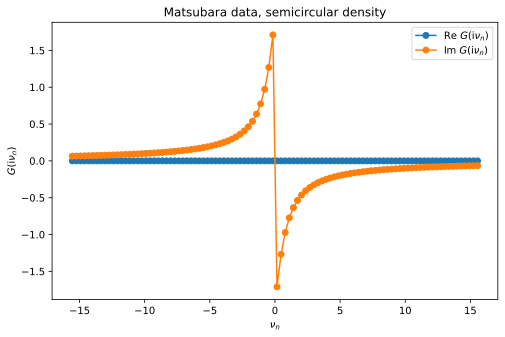

In [3]:
plt.plot(Z.imag, G.real, 'o-', label=r'Re $G(\mathrm{i}\nu_n)$')
plt.plot(Z.imag, G.imag, 'o-', label=r'Im $G(\mathrm{i}\nu_n)$')
plt.xlabel(r'$\nu_n$')
plt.ylabel(r'$G(\mathrm{i}\nu_n)$')
plt.legend()
plt.title('Matsubara data, semicircular density')
plt.show()

## Error metric: the $L^2(\tau)$ norm

Throughout the notebook we measure the quality of a fit by the normalized imaginary time $L^2$ error

$$\left\lVert G_{\mathrm{fit}} - G \right\rVert_{L^2(\tau)} = \left( \frac{1}{\beta}\int_0^\beta \left| G_{\mathrm{fit}}(\tau) - G(\tau) \right|^2 d\tau \right)^{1/2}.$$

A simple pole at $\omega$ with unit residue has the Matsubara-frequency kernel

$$K(\mathrm{i}\nu_n, \omega) = \frac{1}{\mathrm{i}\nu_n - \omega},$$

so that a sum of poles reads $G_{\mathrm{fit}}(\mathrm{i}\nu_n) = \sum_k R_k \, K(\mathrm{i}\nu_n, p_k)$ at the Matsubara frequencies — this is just the sum-of-poles expansion introduced above, evaluated on the imaginary axis. Its Fourier transform is the imaginary time analytic continuation kernel

$$K(\tau, \omega) = -\frac{e^{-\tau\omega}}{1 + e^{-\beta\omega}},$$

so a sum of poles correspondingly maps to $G_{\mathrm{fit}}(\tau) = \sum_k R_k \, K(\tau, p_k)$ in imaginary time.

Below, the exact $G(\tau) = \int \rho(\omega)\, K(\tau,\omega)\, d\omega$ is computed once by Gauss–Chebyshev quadrature — whose weight function $\sqrt{1-\omega^2}$ is exactly the semicircle, so a couple hundred nodes give machine precision — and the $\tau$ integral defining the norm is evaluated by Gauss–Legendre quadrature on $[0, \beta]$. The kernel is evaluated separately for positive and negative $\omega$ to avoid overflowing exponentials.

In [4]:
def K_tau(tau, omega):
    """Imaginary-time kernel K(tau, omega) = -exp(-tau*omega) / (1 + exp(-beta*omega)),
    evaluated in a numerically stable way for both signs of omega."""
    K = np.empty((len(tau), len(omega)))
    p = omega > 0
    m = ~p
    t = tau[:, None]
    K[:, p] = -np.exp(-t * omega[p]) / (1 + np.exp(-beta * omega[p]))
    K[:, m] = -np.exp((beta - t) * omega[m]) / (1 + np.exp(beta * omega[m]))
    return K


# Gauss-Legendre quadrature on [0, beta], for the tau integral
x_gl, w_gl = np.polynomial.legendre.leggauss(200)
tau_q = 0.5 * beta * (x_gl + 1)
w_q = 0.5 * beta * w_gl

# Exact G(tau) at the quadrature nodes, by Gauss-Chebyshev (2nd kind) quadrature in omega
M = 200
j = np.arange(1, M + 1)
om_cheb = np.cos(j * np.pi / (M + 1))
w_cheb = np.pi / (M + 1) * np.sin(j * np.pi / (M + 1))**2
G_tau = (2 / np.pi) * K_tau(tau_q, om_cheb) @ w_cheb


def l2tau_error(poles, residues):
    """Normalized L2(tau) norm  sqrt( (1/beta) int_0^beta |.|^2 dtau )
    of the difference between a sum of simple poles and the exact G."""
    fit_tau = K_tau(tau_q, poles) @ residues
    return np.sqrt(np.sum(w_q * np.abs(fit_tau - G_tau)**2) / beta)


print(f"||G||_L2(tau) = {np.sqrt(np.sum(w_q * np.abs(G_tau)**2) / beta):.6f}")

||G||_L2(tau) = 0.204749


## Fitting frequency data: approx_freq_aaa

`approx_freq_aaa(F, Z, max_n_poles=..., aaa_tol=...)` takes frequency data $F$ sampled at points $Z$ and returns a pole approximation

$$G_{\mathrm{fit}}(z) = \sum_{k=1}^{M} \frac{R_k}{z - p_k}$$

as a tuple `(poles, residues, error)`. It proceeds in two steps: the AAA algorithm determines the pole locations $p_k$ from the data, and the residues $R_k$ are then obtained by a linear least-squares fit against the data. The returned `error` is the **maximum absolute error at the sample points** — a frequency-domain quantity, unlike the $L^2(\tau)$ metric defined above, so we report both below.

At least one of the two stopping criteria must be given:

- `max_n_poles` bounds the number of poles;
- `aaa_tol` is the error tolerance at which the AAA iteration stops.

The number of poles produced is always odd (a consequence of the symmetry-constrained AAA variant used here), and can be smaller than `max_n_poles` if AAA converges early, or if the AAA cleanup step removes poles with negligible residues.

In [5]:
poles, residues, error = approx_freq_aaa(G, Z, aaa_tol=1e-6)

print(f"number of poles:   {len(poles)}")
print(f"error at samples:  {error:.2e}   (max abs, returned by approx_freq_aaa)")
print(f"L2(tau) error:     {l2tau_error(poles, residues):.2e}")
print(f"poles: {np.sort(poles)}")

number of poles:   7
error at samples:  1.39e-07   (max abs, returned by approx_freq_aaa)
L2(tau) error:     4.45e-08
poles: [-0.856458 -0.540225 -0.226438 -0.        0.226438  0.540225  0.856458]


We can verify that the maximum error returned by `approx_freq_aaa` matches the error we obtain directly by evaluating the pole expansion:

In [6]:
direct_error = np.max(np.abs(eval_sop(Z, poles, residues) - G))

print(f"max error from direct evaluation:   {direct_error:.3e}")


max error from direct evaluation:   1.391e-07


### Stopping criterion 1: a pole budget (max_n_poles)

With `max_n_poles` we prescribe a maximum number of poles and take whatever accuracy that budget buys. Sweeping the budget shows the error converging geometrically with the number of poles, down to a roundoff floor of about $10^{-14}$:

max_n_poles =  2  ->   1 poles,  error at samples = 5.56e-01,  L2(tau) error = 9.89e-02
max_n_poles =  4  ->   3 poles,  error at samples = 2.31e-02,  L2(tau) error = 3.52e-03
max_n_poles =  6  ->   5 poles,  error at samples = 5.49e-05,  L2(tau) error = 1.25e-05
max_n_poles =  8  ->   7 poles,  error at samples = 1.39e-07,  L2(tau) error = 4.45e-08
max_n_poles = 10  ->   9 poles,  error at samples = 4.04e-11,  L2(tau) error = 9.18e-12
max_n_poles = 12  ->  11 poles,  error at samples = 7.01e-15,  L2(tau) error = 3.02e-15
max_n_poles = 14  ->  11 poles,  error at samples = 1.29e-14,  L2(tau) error = 9.11e-15
max_n_poles = 16  ->  11 poles,  error at samples = 4.12e-14,  L2(tau) error = 5.34e-15


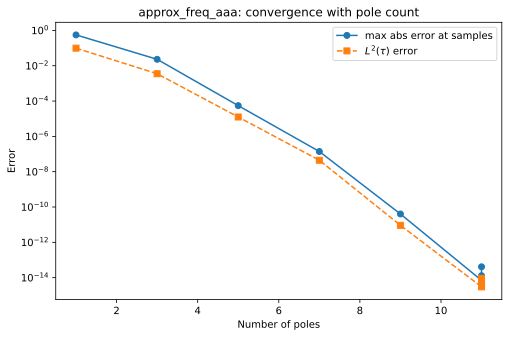

In [7]:
n_poles, err_freq, err_tau = [], [], []
for max_np in range(2, 18, 2):
    p, r, err = approx_freq_aaa(G, Z, max_n_poles=max_np)
    n_poles.append(len(p))
    err_freq.append(err)
    err_tau.append(l2tau_error(p, r))
    print(f"max_n_poles = {max_np:2d}  ->  {len(p):2d} poles,  "
          f"error at samples = {err:.2e},  L2(tau) error = {err_tau[-1]:.2e}")

plt.plot(n_poles, err_freq, 'o-', label='max abs error at samples')
plt.plot(n_poles, err_tau, 's--', label=r'$L^2(\tau)$ error')
plt.yscale('log')
plt.xlabel('Number of poles')
plt.ylabel('Error')
plt.legend()
plt.title('approx_freq_aaa: convergence with pole count')
plt.show()

Note that the budget is not always saturated: `max_n_poles = 14` and `16` both return 11 poles, since by then AAA has hit the roundoff floor and additional poles would not improve the fit.

### Stopping criterion 2: an AAA tolerance (aaa_tol)

With `aaa_tol`, the AAA iteration instead runs until its internal error estimate drops below the requested tolerance. We saw this above, but will now sweep over values of this parameter. Note that `aaa_tol` controls the *pole step* only: it bounds the AAA interpolation error on the data, not the final $L^2$ error after the residue refit. It is a stopping heuristic rather than a guarantee (though in this case we see that it acts as an upper bound).

aaa_tol = 1e-03  ->   5 poles,  error at samples = 5.49e-05,  L2(tau) error = 1.25e-05
aaa_tol = 1e-06  ->   7 poles,  error at samples = 1.39e-07,  L2(tau) error = 4.45e-08
aaa_tol = 1e-09  ->   9 poles,  error at samples = 4.04e-11,  L2(tau) error = 9.18e-12
aaa_tol = 1e-12  ->  11 poles,  error at samples = 7.01e-15,  L2(tau) error = 3.02e-15


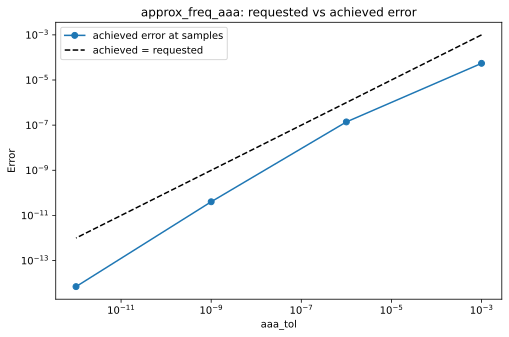

In [8]:
tols = [1e-3, 1e-6, 1e-9, 1e-12]
achieved = []
for tol in tols:
    p, r, err = approx_freq_aaa(G, Z, aaa_tol=tol)
    achieved.append(err)
    print(f"aaa_tol = {tol:.0e}  ->  {len(p):2d} poles,  error at samples = {err:.2e},  "
          f"L2(tau) error = {l2tau_error(p, r):.2e}")

plt.plot(tols, achieved, 'o-', label='achieved error at samples')
plt.plot(tols, tols, 'k--', label='achieved = requested')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('aaa_tol')
plt.ylabel('Error')
plt.legend()
plt.title('approx_freq_aaa: requested vs achieved error')
plt.show()

### Combining both criteria

If both criteria are given, AAA stops at whichever is reached first — useful for requesting a tolerance while capping the cost.

In [9]:
p, r, err = approx_freq_aaa(G, Z, max_n_poles=20, aaa_tol=1e-8)
print(f"max_n_poles=20, aaa_tol=1e-8  ->  {len(p)} poles, error = {err:.2e}   (tolerance reached first)")

p, r, err = approx_freq_aaa(G, Z, max_n_poles=6, aaa_tol=1e-12)
print(f"max_n_poles=6,  aaa_tol=1e-12 ->  {len(p)} poles, error = {err:.2e}   (pole budget reached first)")

max_n_poles=20, aaa_tol=1e-8  ->  9 poles, error = 4.04e-11   (tolerance reached first)
AAA: Warning! Failed to converge after 3 steps. Final error 7.94E-05 larger than tolerance 1.00E-12.
max_n_poles=6,  aaa_tol=1e-12 ->  5 poles, error = 5.49e-05   (pole budget reached first)


## Compressing a sum of poles: approx_sop_fast

The remaining two functions, `approx_sop_fast` and `approx_sop_tol`, take as input not raw data but an existing *sum-of-poles expansion* — poles $P_k$ and weights $W_k$ with $G(z) \approx \sum_{k} W_k / (z - P_k)$. So we first build a trial expansion from the Matsubara data, then compress it.

For the trial expansion, we use a quick and dirty version of the discrete Lehmann representation. On a dense candidate grid $\omega_j \in [-1, 1]$, we form the matrix of simple poles $K_{nj} = 1/(\mathrm{i}\nu_n - \omega_j)$ sampled on a dense Matsubara grid, keep a well-conditioned subset of poles via a rank-revealing column-pivoted QR (those with $|R_{jj}| > \epsilon_{\mathrm{QR}}|R_{00}|$), and fit their weights to the data for $G$ by least squares.

In [10]:
# dense fermionic Matsubara grid and dense candidate pole grid
n_dense = np.arange(-200, 200)
Z_dense = 1j * (2 * n_dense + 1) * np.pi / beta
G_dense = G_exact(Z_dense)

om_cand = np.linspace(-1, 1, 501)
Kmat = 1.0 / (Z_dense[:, None] - om_cand[None, :])

# rank-revealing pivoted QR selects the linearly independent candidate poles
qr_tol = 1e-12
Q, R, piv = scipy.linalg.qr(Kmat, mode='economic', pivoting=True)
rank = int(np.sum(np.abs(np.diag(R)) > qr_tol * np.abs(R[0, 0])))
poles_in = np.sort(om_cand[piv[:rank]])

# least-squares fit for the weights
Ksel = 1.0 / (Z_dense[:, None] - poles_in[None, :])
weights_in, *_ = np.linalg.lstsq(Ksel, G_dense, rcond=None)

print(f"selected {rank} of {len(om_cand)} candidate poles")
print(f"max |Im weights|: {np.abs(weights_in.imag).max():.1e}")
weights_in = weights_in.real   # discard the tiny imaginary parts (see below)

print(f"max |G - SOP| on the dense grid: {np.abs(eval_sop(Z_dense, poles_in, weights_in) - G_dense).max():.1e}")
print(f"L2(tau) error of the input SOP:  {l2tau_error(poles_in, weights_in):.1e}")

selected 21 of 501 candidate poles
max |Im weights|: 2.9e-07
max |G - SOP| on the dense grid: 1.9e-14
L2(tau) error of the input SOP:  2.0e-15


These 21 poles reproduce $G$ to near machine precision, so the expansion is a faithful proxy whose $L^2(\tau)$ error, $\sim 2\times10^{-15}$, is the accuracy floor for everything below. However, even at this tight tolerance, it is known that a fit using poles *customized to $G$ itself* outperforms the generic DLR-style construction, in the sense that the same accuracy can be achieved with fewer poles [[2]](#references). `approx_sop_fast` and `approx_sop_tol` attempt to compress a given pole approximation.

`approx_sop_fast(poles, residues, beta, ...)` does this in a single pass:

1. **Pole step:** the input expansion is evaluated on a symmetric fermionic Matsubara grid $\mathrm{i}(2n+1)\pi/\beta$, $-n_{\max} \le n \le n_{\max}-1$, with $n_{\max} = \lfloor 4\beta\omega_{\max}/\pi\rfloor + 1$ and $\omega_{\max} = \max_k |P_k|$ (here $n_{\max} = 26$, i.e. 52 points; a custom grid can be supplied via the `Z` argument), and AAA is run on this data to determine the new pole locations.
2. **Residue step:** the residues are determined by minimizing the $L^2(\tau)$ norm of the deviation from the input expansion — a *linear* least-squares problem once the poles are fixed. With `nonlinear_optimization=True`, the pole locations and residues are instead optimized *jointly* (L-BFGS-B with an analytic gradient, keeping the number of poles fixed), using the AAA poles as the initial guess.

Note that the residue fit happens in imaginary time — unlike `approx_freq_aaa`, which fits the residues to the frequency data. Accordingly, the returned `error` is the $L^2(\tau)$ norm of the deviation from the *input expansion*; it is the same norm as our metric, which instead measures against the exact $G$.

The stopping criteria `max_n_poles` and `aaa_tol` work exactly as in `approx_freq_aaa`, with `aaa_tol` again controlling only the AAA pole step.

In [11]:
t0 = time.perf_counter()
p, r, err = approx_sop_fast(poles_in, weights_in, beta, aaa_tol=1e-8)
dt = (time.perf_counter() - t0) * 1e3

print(f"{len(poles_in)} input poles compressed to {len(p)} poles in {dt:.1f} ms")
print(f"returned L2(tau) error (vs the input SOP): {err:.2e}")
print(f"L2(tau) error vs the exact G:              {l2tau_error(p, r):.2e}")

21 input poles compressed to 9 poles in 1.7 ms
returned L2(tau) error (vs the input SOP): 9.37e-12
L2(tau) error vs the exact G:              9.37e-12


### Convergence, and the effect of nonlinear optimization

We sweep the pole budget with the nonlinear optimization switched off and on. (Timings here and below are rough single-shot measurements.)

nonlinear_optimization=False  max_n_poles= 2  ->   1 poles,  error vs exact G = 9.88e-02,  t =   4.9 ms
nonlinear_optimization=False  max_n_poles= 4  ->   3 poles,  error vs exact G = 3.52e-03,  t =   2.4 ms
nonlinear_optimization=False  max_n_poles= 6  ->   5 poles,  error vs exact G = 1.24e-05,  t =   1.2 ms
nonlinear_optimization=False  max_n_poles= 8  ->   7 poles,  error vs exact G = 4.44e-08,  t =   1.1 ms
nonlinear_optimization=False  max_n_poles=10  ->   9 poles,  error vs exact G = 9.37e-12,  t =   1.2 ms
nonlinear_optimization=False  max_n_poles=12  ->  11 poles,  error vs exact G = 3.56e-15,  t =   1.4 ms
nonlinear_optimization=False  max_n_poles=14  ->  13 poles,  error vs exact G = 2.01e-15,  t =   1.6 ms
nonlinear_optimization=False  max_n_poles=16  ->  13 poles,  error vs exact G = 2.00e-15,  t =   2.1 ms

nonlinear_optimization=True   max_n_poles= 2  ->   1 poles,  error vs exact G = 9.88e-02,  t =   1.1 ms
nonlinear_optimization=True   max_n_poles= 4  ->   3 poles,  er

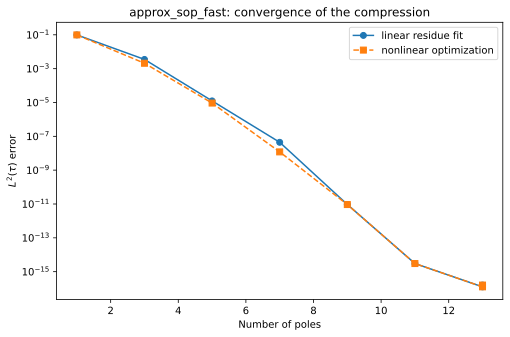

In [12]:
results = {}
for nlo in [False, True]:
    ns, errs, times = [], [], []
    for max_np in range(2, 18, 2):
        t0 = time.perf_counter()
        p, r, err = approx_sop_fast(poles_in, weights_in, beta,
                                    max_n_poles=max_np, nonlinear_optimization=nlo)
        dt = (time.perf_counter() - t0) * 1e3
        ns.append(len(p)); errs.append(err); times.append(dt)
        print(f"nonlinear_optimization={str(nlo):5s}  max_n_poles={max_np:2d}  ->  "
              f"{len(p):2d} poles,  error vs exact G = {l2tau_error(p, r):.2e},  "
              f"t = {dt:5.1f} ms")
    results[nlo] = (ns, errs, times)
    print()

plt.plot(results[False][0], results[False][1], 'o-', label='linear residue fit')
plt.plot(results[True][0], results[True][1], 's--', label='nonlinear optimization')
plt.yscale('log')
plt.xlabel('Number of poles')
plt.ylabel(r'$L^2(\tau)$ error')
plt.legend()
plt.title('approx_sop_fast: convergence of the compression')
plt.show()

For this smooth, particle-hole-symmetric density the AAA poles are already nearly optimal, so we see there is not much to gain from running the nonlinear optimization step. In general, it is worth experimenting with.

## Compressing to a prescribed accuracy: approx_sop_tol

For `approx_sop_fast`, the tolerance `aaa_tol` is only a stopping heuristic for the pole step. `approx_sop_tol(poles, residues, tol, beta, ...)` instead imposes the tolerance on the **final** $L^2(\tau)$ error, and returns the *smallest* pole expansion meeting it. Since the final error is only known after the residue fit, the AAA + residue-fit pipeline is run repeatedly: the number of AAA steps is increased until the error drops below `tol`, and a bisection then locates the smallest number of steps that still meets it. If the tolerance cannot be met (for instance, because it lies below the roundoff floor), a `ValueError` is raised.

The search costs several `approx_sop_fast`-like passes, as the timing comparison below shows. With `verbose=True` the progress of the search is printed:

In [13]:
t0 = time.perf_counter()
p, r, err = approx_sop_tol(poles_in, weights_in, tol=1e-6, beta=beta,
                           nonlinear_optimization=True, verbose=True)
dt_tol = (time.perf_counter() - t0) * 1e3
print(f"\napprox_sop_tol(tol=1e-6):        {len(p)} poles,  error = {err:.2e},  t = {dt_tol:5.1f} ms")

# a single fast pass reaching the same accuracy, for timing comparison
t0 = time.perf_counter()
p2, r2, err2 = approx_sop_fast(poles_in, weights_in, beta, aaa_tol=1e-6,
                               nonlinear_optimization=True)
dt_fast = (time.perf_counter() - t0) * 1e3
print(f"approx_sop_fast(aaa_tol=1e-6):   {len(p2)} poles,  error = {err2:.2e},  t = {dt_fast:5.1f} ms")

AAA: Error 6.98E-01 using 1 support and 50 fitting points (step 1/51)
AAA: Error 1.67E-02 using 2 support and 48 fitting points (step 2/51)
AAA: Error 7.87E-05 using 3 support and 46 fitting points (step 3/51)
AAA: Error 1.36E-07 using 4 support and 44 fitting points (step 4/51)
AAA: Converged after 4 steps with error 1.36E-07.
Adapol: Error 1.20E-08 for 4 AAA steps (Error 7.87E-05 no opt) c.f. tol 1.00E-06.
AAA: Error 6.98E-01 using 1 support and 50 fitting points (step 1/2)
AAA: Error 1.67E-02 using 2 support and 48 fitting points (step 2/2)
Adapol: Error 2.09E-03 for 2 AAA steps (Error 6.98E-01 no opt) c.f. tol 1.00E-06.
AAA: Error 6.98E-01 using 1 support and 50 fitting points (step 1/3)
AAA: Error 1.67E-02 using 2 support and 48 fitting points (step 2/3)
AAA: Error 7.87E-05 using 3 support and 46 fitting points (step 3/3)
Adapol: Error 9.25E-06 for 3 AAA steps (Error 1.67E-02 no opt) c.f. tol 1.00E-06.
AAA: Error 6.98E-01 using 1 support and 50 fitting points (step 1/3)
AAA: Error

The log shows the search: a first upward sweep in the number of AAA steps until the tolerance is met, followed by re-runs that bisect the step count down to the smallest sufficient one. The result costs a few times more than a single `approx_sop_fast` pass, but comes with an actual guarantee on the final error rather than a heuristic.

### Pole count vs tolerance

Sweeping the tolerance maps out how many poles a given accuracy requires — a staircase, since poles are added in symmetric pairs. In contrast to the heuristic `aaa_tol` of `approx_sop_fast`, the achieved error now always sits at or below the requested tolerance:

nonlinear_optimization=False  tol = 1e-02  ->   3 poles,  error = 3.52e-03,  t =   3.7 ms
nonlinear_optimization=False  tol = 1e-03  ->   5 poles,  error = 1.24e-05,  t =   2.5 ms
nonlinear_optimization=False  tol = 1e-04  ->   5 poles,  error = 1.24e-05,  t =   2.3 ms
nonlinear_optimization=False  tol = 1e-05  ->   7 poles,  error = 4.44e-08,  t =   2.5 ms
nonlinear_optimization=False  tol = 1e-06  ->   7 poles,  error = 4.44e-08,  t =   2.6 ms
nonlinear_optimization=False  tol = 1e-07  ->   7 poles,  error = 4.44e-08,  t =   4.3 ms
nonlinear_optimization=False  tol = 1e-08  ->   9 poles,  error = 9.37e-12,  t =   4.2 ms
nonlinear_optimization=False  tol = 1e-09  ->   9 poles,  error = 9.37e-12,  t =   3.7 ms
nonlinear_optimization=False  tol = 1e-10  ->   9 poles,  error = 9.37e-12,  t =   3.7 ms
nonlinear_optimization=False  tol = 1e-11  ->   9 poles,  error = 9.37e-12,  t =   4.1 ms
nonlinear_optimization=False  tol = 1e-12  ->  11 poles,  error = 3.02e-15,  t =   4.2 ms

nonlinear

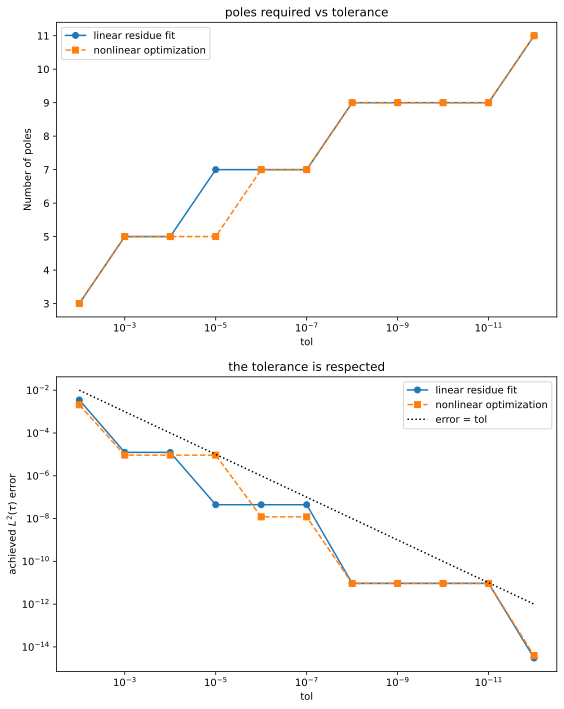

In [14]:
tols = 10.0 ** (-np.arange(2, 13, dtype=float))
stair = {}
for nlo in [False, True]:
    ns, errs, times = [], [], []
    for tol in tols:
        t0 = time.perf_counter()
        p, r, err = approx_sop_tol(poles_in, weights_in, tol=tol, beta=beta,
                                   nonlinear_optimization=nlo)
        dt = (time.perf_counter() - t0) * 1e3
        ns.append(len(p)); errs.append(err); times.append(dt)
        print(f"nonlinear_optimization={str(nlo):5s}  tol = {tol:.0e}  ->  "
              f"{len(p):2d} poles,  error = {err:.2e},  t = {dt:5.1f} ms")
    stair[nlo] = (ns, errs, times)
    print()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
ax1.plot(tols, stair[False][0], 'o-', label='linear residue fit')
ax1.plot(tols, stair[True][0], 's--', label='nonlinear optimization')
ax1.set_xscale('log')
ax1.invert_xaxis()
ax1.set_xlabel('tol')
ax1.set_ylabel('Number of poles')
ax1.legend()
ax1.set_title('poles required vs tolerance')

ax2.plot(tols, stair[False][1], 'o-', label='linear residue fit')
ax2.plot(tols, stair[True][1], 's--', label='nonlinear optimization')
ax2.plot(tols, tols, 'k:', label='error = tol')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.invert_xaxis()
ax2.set_xlabel('tol')
ax2.set_ylabel(r'achieved $L^2(\tau)$ error')
ax2.legend()
ax2.set_title('the tolerance is respected')

plt.tight_layout()
plt.show()

We also observe that the nonlinear optimization can sometimes produce a more compact pole approximation at the same tolerance.

## Summary

- `approx_freq_aaa` fits raw Matsubara (or other frequency) data directly; its error is measured at the sample points.
- `approx_sop_fast` is a cheap single-pass compression of an existing pole expansion; `max_n_poles` acts as a budget, `aaa_tol` as a stopping heuristic for the pole search.
- `approx_sop_tol` returns the smallest expansion meeting a prescribed final $L^2(\tau)$ accuracy, at the cost of a few fast passes.
- `nonlinear_optimization=True` refines the AAA pole locations, if possible.

## References

[1] J. Kaye, K. Chen, and O. Parcollet, [Discrete Lehmann representation of imaginary time Green's functions](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.105.235115), Phys. Rev. B **105**, 235115 (2022).

[2] Z. Huang, D. Golež, H. U. R. Strand, J. Kaye, [Automated evaluation of imaginary time strong coupling diagrams by sum-of-exponentials hybridization fitting](https://scipost.org/SciPostPhys.19.5.121), SciPost Phys., 19 (5), 121 (2025).